Contents of the zip file:
SpotifyAudioFeaturesApril2019.csv
SpotifyAudioFeaturesNov2018.csv
Successfully loaded 'SpotifyAudioFeaturesApril2019.csv' from the zip archive.
  artist_name                track_id  \
0          YG  2RM4jf1Xa9zPgMGRDiht8O   
1          YG  1tHDG53xJNGsItRA3vfVgs   
2       R3HAB  6Wosx2euFPMT14UXiWudMy   
3  Chris Cooq  3J2Jpw61sO7l6Hc7qdYV91   
4  Chris Cooq  2jbYvQCyPgX3CdmAzeVeuS   

                                       track_name  acousticness  danceability  \
0  Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj      0.005820         0.743   
1                    BAND DRUM (feat. A$AP Rocky)      0.024400         0.846   
2                                   Radio Silence      0.025000         0.603   
3                                         Lactose      0.029400         0.800   
4                             Same - Original mix      0.000035         0.783   

   duration_ms  energy  instrumentalness  key  liveness  loudness  mode  \
0       238373   0.33

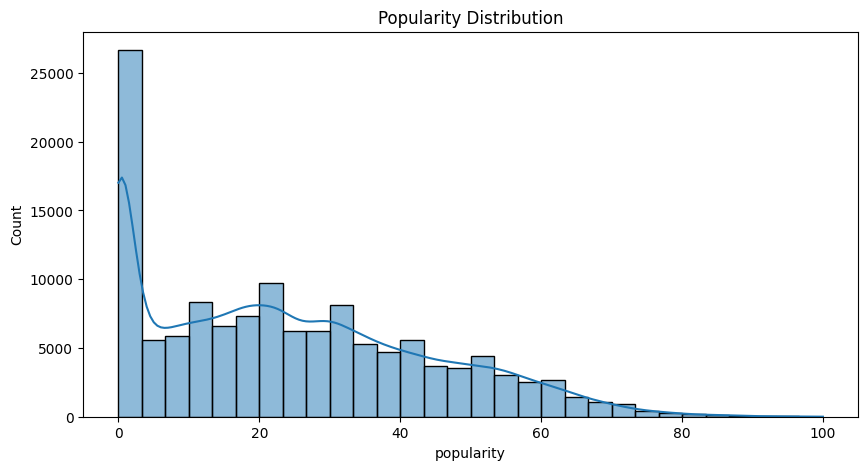

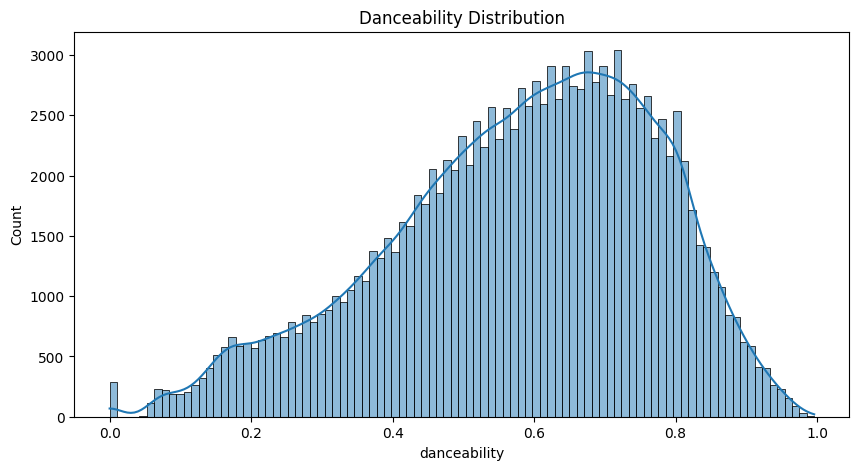

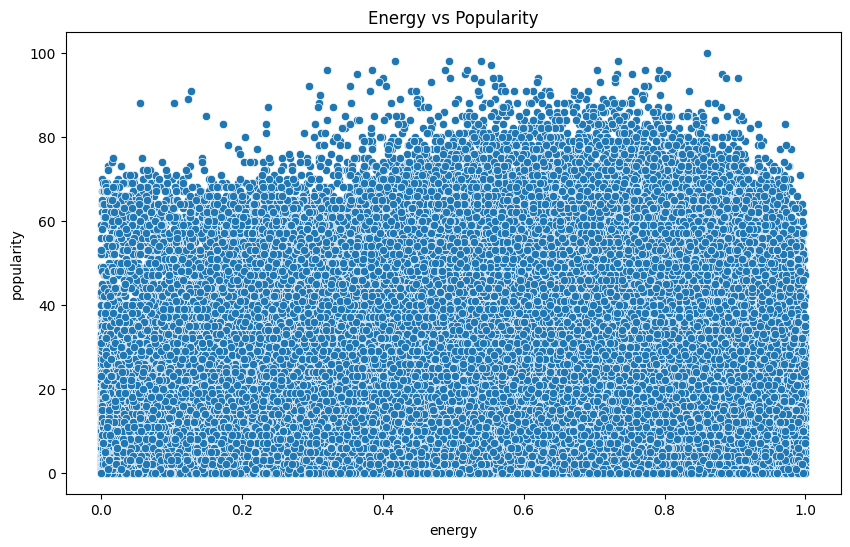

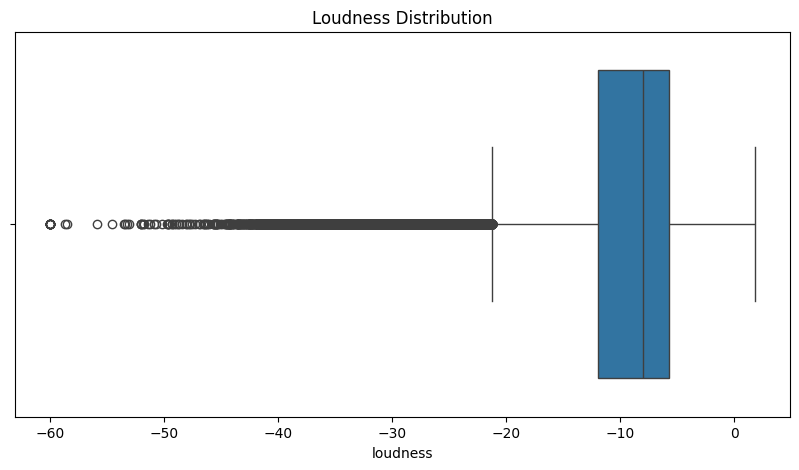

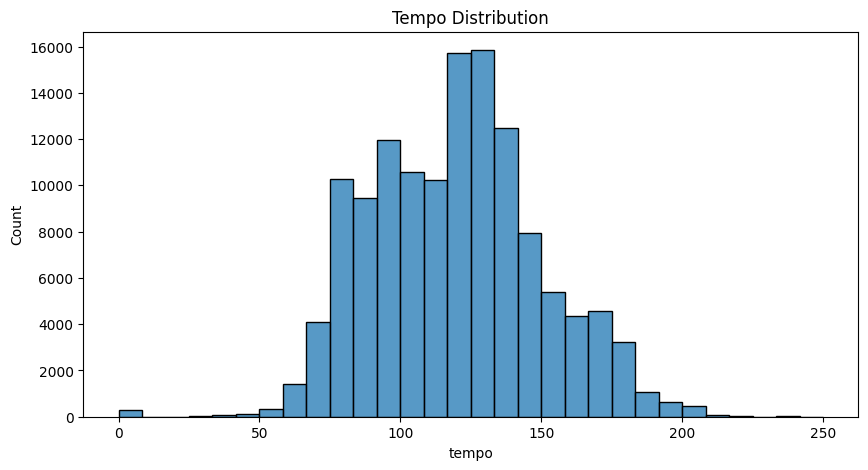

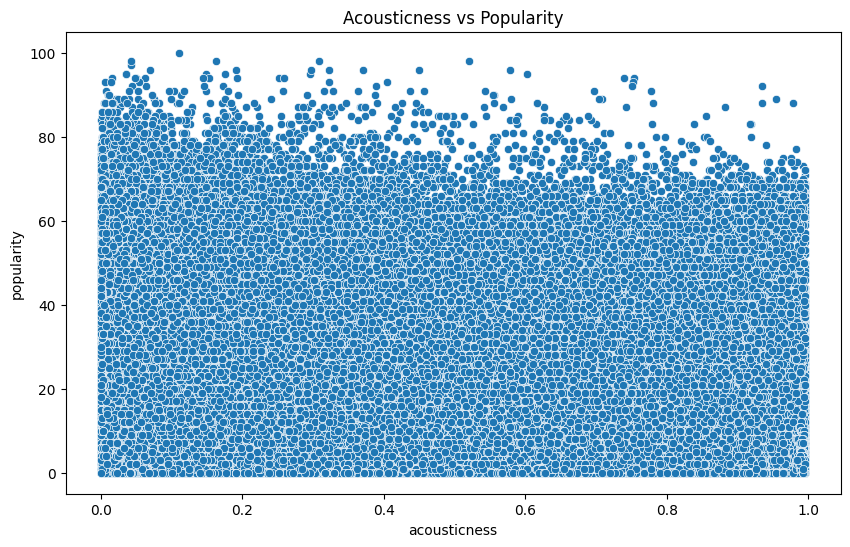

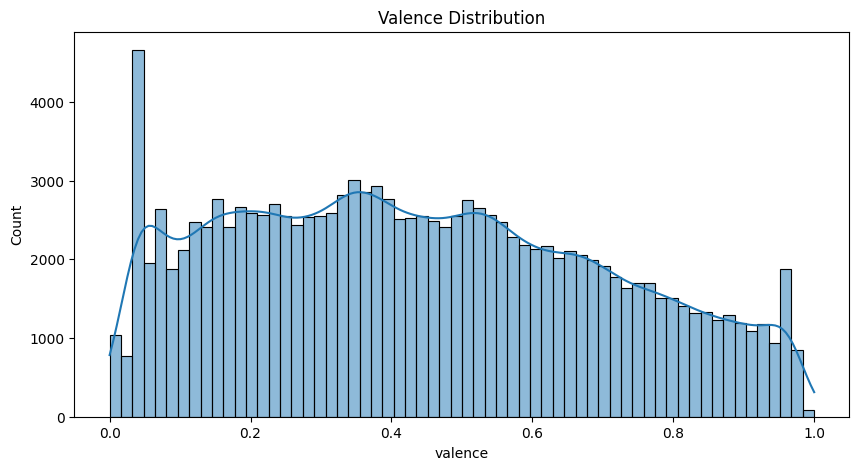

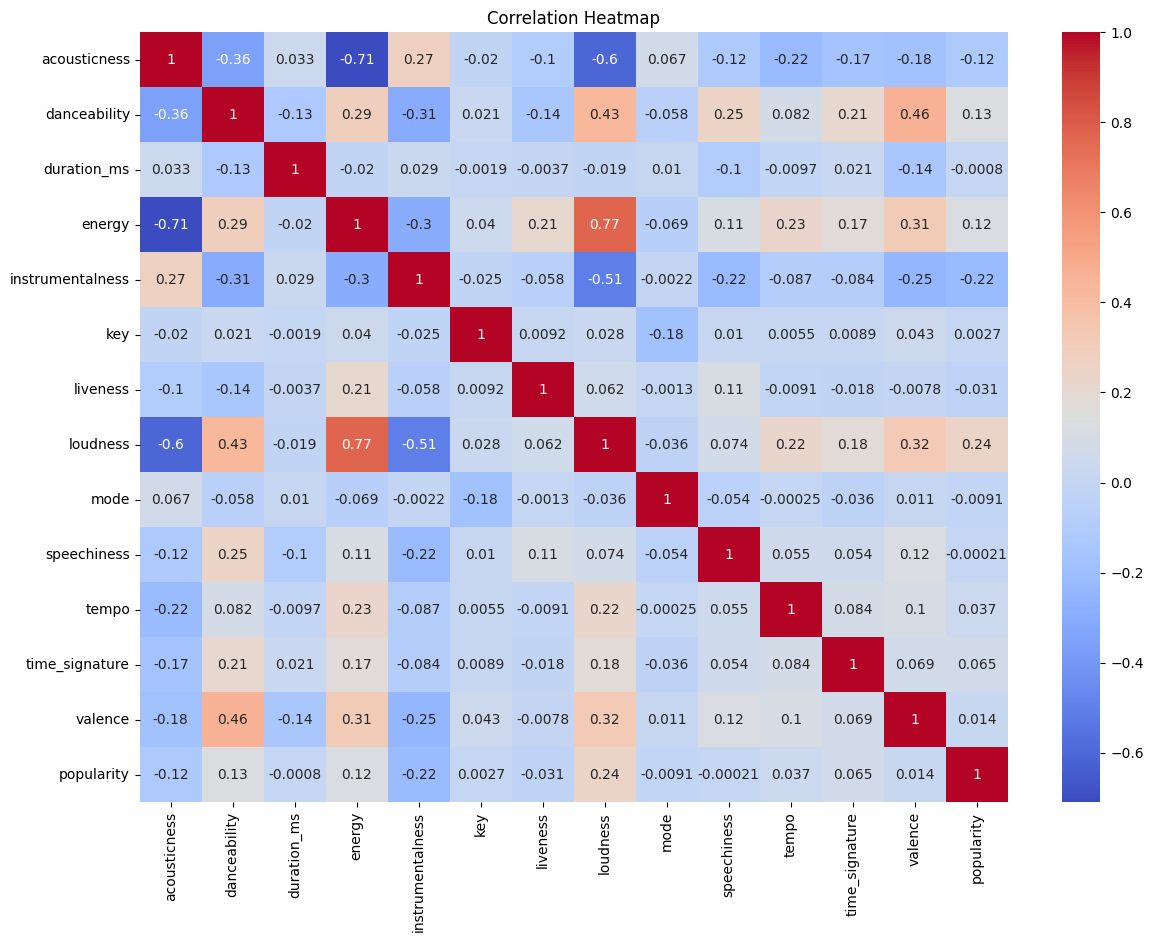

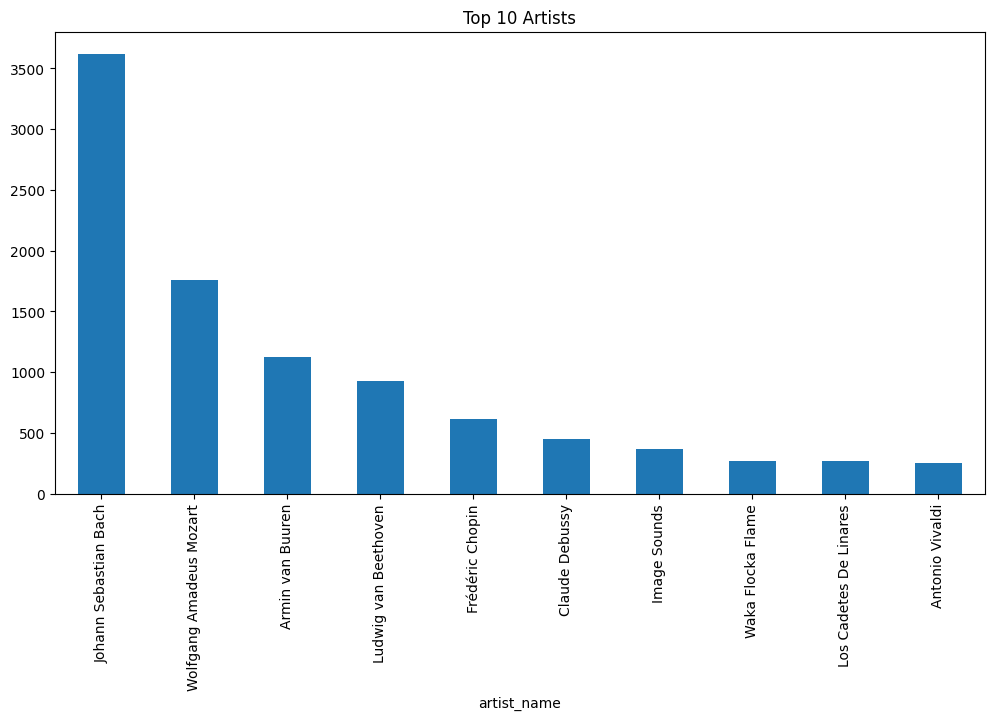

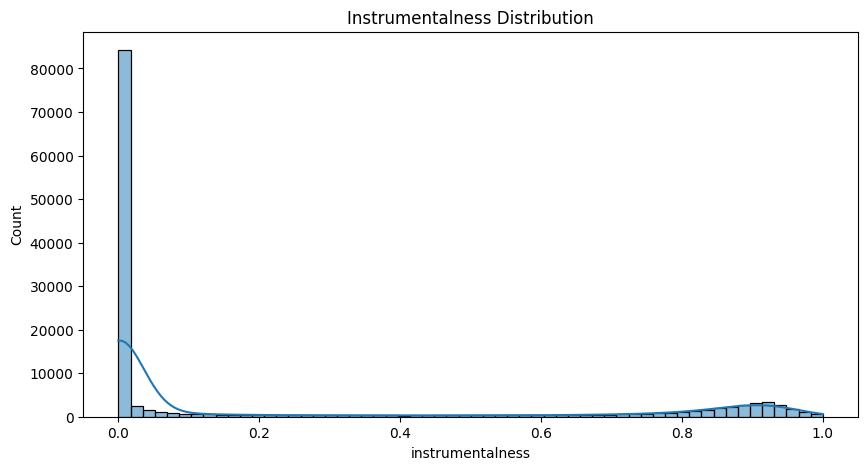

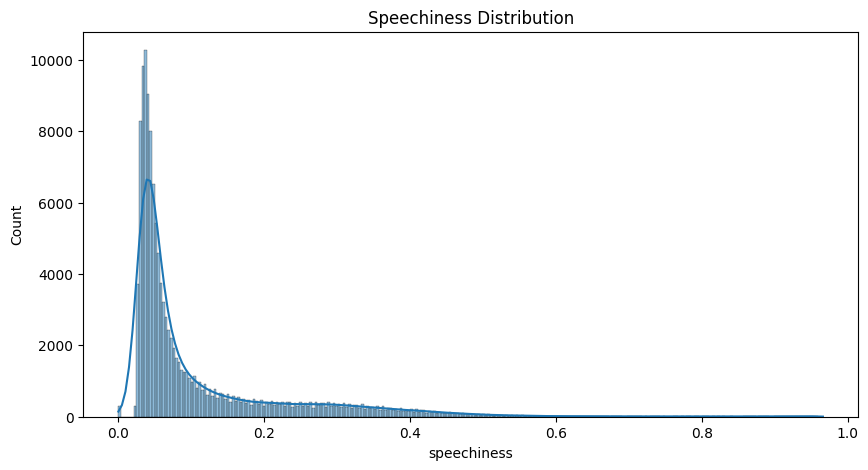

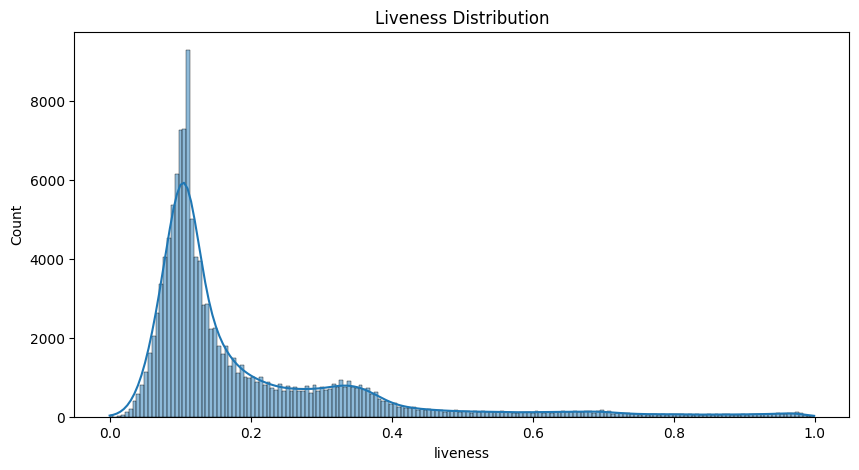

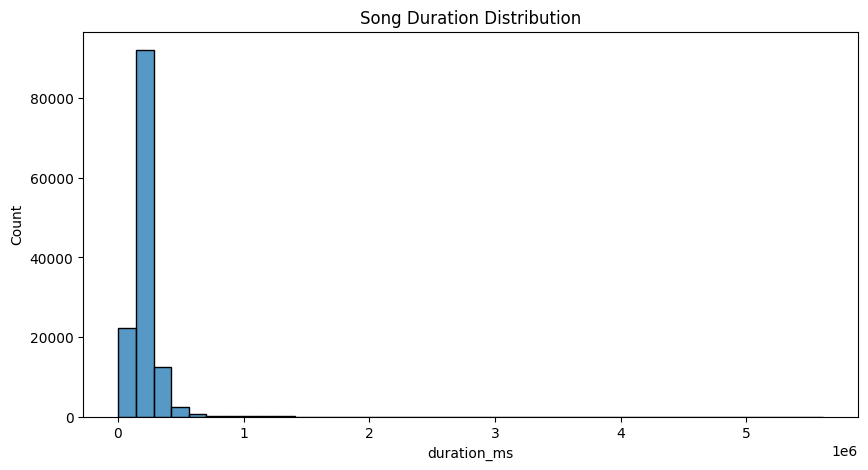

EDA Completed Successfully!


In [12]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import zipfile

# Load Dataset
# The uploaded file is a zip file, so we need to extract the CSV from it.
zip_file = zipfile.ZipFile('/content/SpotifyFeatures.zip')

# List contents of the zip file to find the correct CSV name
zip_contents = zip_file.namelist()
print("Contents of the zip file:")
for name in zip_contents:
    print(name)

csv_file_in_zip = None
for name in zip_contents:
    if name.lower().endswith('.csv'):
        csv_file_in_zip = name
        break

if csv_file_in_zip:
    df = pd.read_csv(zip_file.open(csv_file_in_zip))
    print(f"Successfully loaded '{csv_file_in_zip}' from the zip archive.")
else:
    print("Error: No CSV file found in the zip archive. Please check the contents listed above.")
    df = pd.DataFrame() # Initialize an empty DataFrame to prevent further errors if no CSV is found.

# Display first rows
print(df.head())

# Dataset Info
print(df.info())

# Statistical Summary
print(df.describe())

# Missing Values
print(df.isnull().sum())

# Duplicate Values
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# -------------------------------
# VISUALIZATION 1
# Genre Distribution (Removed as 'genre' column is not found in the dataset)
# -------------------------------
# plt.figure(figsize=(12,6))
# df['genre'].value_counts().head(10).plot(kind='bar')
# plt.title("Top 10 Genres")
# plt.xlabel("Genre")
# plt.ylabel("Count")
# plt.show()

# -------------------------------
# VISUALIZATION 2
# Popularity Distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title("Popularity Distribution")
plt.show()

# -------------------------------
# VISUALIZATION 3
# Danceability Distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['danceability'], kde=True)
plt.title("Danceability Distribution")
plt.show()

# -------------------------------
# VISUALIZATION 4
# Energy vs Popularity
# -------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(x='energy', y='popularity', data=df)
plt.title("Energy vs Popularity")
plt.show()

# -------------------------------
# VISUALIZATION 5
# Loudness Distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.boxplot(x=df['loudness'])
plt.title("Loudness Distribution")
plt.show()

# -------------------------------
# VISUALIZATION 6
# Tempo Distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['tempo'], bins=30)
plt.title("Tempo Distribution")
plt.show()

# -------------------------------
# VISUALIZATION 7
# Acousticness vs Popularity
# -------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(x='acousticness', y='popularity', data=df)
plt.title("Acousticness vs Popularity")
plt.show()

# -------------------------------
# VISUALIZATION 8
# Valence Distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['valence'], kde=True)
plt.title("Valence Distribution")
plt.show()

# -------------------------------
# VISUALIZATION 9
# Correlation Heatmap
# -------------------------------
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# VISUALIZATION 10
# Top Artists
# -------------------------------
plt.figure(figsize=(12,6))
df['artist_name'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Artists")
plt.show()

# -------------------------------
# VISUALIZATION 11
# Instrumentalness Distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['instrumentalness'], kde=True)
plt.title("Instrumentalness Distribution")
plt.show()

# -------------------------------
# VISUALIZATION 12
# Speechiness Distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['speechiness'], kde=True)
plt.title("Speechiness Distribution")
plt.show()

# -------------------------------
# VISUALIZATION 13
# Liveness Distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['liveness'], kde=True)
plt.title("Liveness Distribution")
plt.show()

# -------------------------------
# VISUALIZATION 14
# Duration Distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['duration_ms'], bins=40)
plt.title("Song Duration Distribution")
plt.show()

# -------------------------------
# VISUALIZATION 15
# Explicit Songs Count (Removed as 'genre' column is not found in the dataset)
# -------------------------------
# top_genres = df['genre'].value_counts().head(5)
#
# plt.figure(figsize=(8,8))
#
# plt.pie(top_genres, labels=top_genres.index, autopct='%1.1f%%')
#
# plt.title("Top 5 Genres Share")
#
# plt.show()
print("EDA Completed Successfully!")